In [1]:
import netCDF4 as nc
import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
['VHM0_SW1','VHM0_WW']
['VTM01_WW','VTM02','VTM01_SW1','VTM10']

In [3]:
feature_names = ['VPED','VSDX','VSDY',
    'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW',
    'VTM02', 'VTM10', 'VTPK','VMDR_SW1', 'VCMX', 'VHM0',
    'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW',
    'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL','TLA', 'TAUX', 'TAUY']

In [4]:
WAVE_VARS = [
    'VPED', 'VSDX', 'VSDY',
    'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW',
    'VTM02', 'VTM10', 'VTPK'
]

WAVE_VARS1 = [
    'VMDR_SW1', 'VCMX', 'VHM0',
    'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW',
    'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL'
]

EXTRA_VARS = ["TLA", "TAUX", "TAUY"]

In [5]:
ds  = nc.Dataset(r'new_dAtA/after_xl.nc')
ds1 = nc.Dataset(r'new_dAtA/till xl.nc')
ds3 = nc.Dataset(r'new_dAtA/tla_taux_tauy.nc')

getfattr: new_dAtA/till: No such file or directory
getfattr: xl.nc: No such file or directory


In [6]:
time_dim = ds.dimensions["time"].size
lat_dim  = ds.dimensions["latitude"].size
lon_dim  = ds.dimensions["longitude"].size

In [7]:
print(f"Time dim: {time_dim}, Lat dim: {lat_dim}, Lon dim: {lon_dim}")

Time dim: 35017, Lat dim: 162, Lon dim: 162


In [8]:
# time_dim=10000


def load_time_slice(ds, var_list, t):
    data = []
    for v in var_list:
        data.append(ds.variables[v][t, :, :])
    return np.stack(data, axis=0)  # (C, H, W)

In [9]:
bathy_ds = nc.Dataset("new_dAtA/cmems_GEBCO_resampled_new.nc")
deptho = bathy_ds.variables["deptho"][:]  # (H, W)

assert deptho.shape == (lat_dim, lon_dim)

In [10]:
epsilon = 1e-6

def angular_difference(a, b):
    diff = np.abs(a - b)
    return np.minimum(diff, 360 - diff)

In [11]:
def compute_engineered_features(t):
    """
    Returns engineered feature tensor of shape (11, H, W)
    """

    # --- Directional & swell vars ---
    VMDR_SW1 = ds1.variables["VMDR_SW1"][t]
    VMDR_SW2 = ds1.variables["VMDR_SW2"][t]
    VMDR_WW  = ds1.variables["VMDR_WW"][t]

    VHM0_SW1 = ds1.variables["VHM0_SW1"][t]
    VHM0_SW2 = ds1.variables["VHM0_SW2"][t]

    # --- Stokes drift ---
    VSDX = ds.variables["VSDX"][t]
    VSDY = ds.variables["VSDY"][t]

    # --- Spectral ---
    VTPK  = ds.variables["VTPK"][t]
    VTM02 = ds.variables["VTM02"][t]

    # --- Dissipation ---
    TLA = ds3.variables["TLA"][t]

    # --- Wind stress ---
    TAUX = ds3.variables["TAUX"][t]
    TAUY = ds3.variables["TAUY"][t]

    # ==============================
    # Feature construction
    # ==============================

    delta_theta_SW = angular_difference(VMDR_SW1, VMDR_SW2)
    swell_energy_ratio = VHM0_SW2 / (VHM0_SW1 + epsilon)
    delta_theta_SW1_WW = angular_difference(VMDR_SW1, VMDR_WW)

    stokes_drift_mag = np.sqrt(VSDX**2 + VSDY**2)
    inv_stokes_drift = 1.0 / (stokes_drift_mag + epsilon)

    spectral_sharpness = VTPK / (VTM02 + epsilon)

    log_TLA = np.log(TLA + epsilon)
    TLA_x_swell_ratio = log_TLA * swell_energy_ratio
    TLA_x_delta_theta = log_TLA * delta_theta_SW

    TAU_mag = np.sqrt(TAUX**2 + TAUY**2)
    sin_TAU = np.sin(np.arctan2(TAUY, TAUX))
    cos_TAU = np.cos(np.arctan2(TAUY, TAUX))

    sin_VSD = np.sin(np.arctan2(VSDY, VSDX))
    cos_VSD = np.cos(np.arctan2(VSDY, VSDX))

    return np.stack([
        delta_theta_SW,
        swell_energy_ratio,
        delta_theta_SW1_WW,
        stokes_drift_mag,
        inv_stokes_drift,
        spectral_sharpness,
        log_TLA,
        TLA_x_swell_ratio,
        TLA_x_delta_theta,
        TAU_mag,
        sin_TAU,
        cos_TAU,
        sin_VSD,
        cos_VSD
    ], axis=0)

In [12]:
def build_input_tensor(t):
    x0 = load_time_slice(ds,  WAVE_VARS,  t)    # (9, H, W)
    x1 = load_time_slice(ds1, WAVE_VARS1, t)    # (10, H, W)
    x2 = load_time_slice(ds3, EXTRA_VARS, t)    # (3, H, W)

    x_eng = compute_engineered_features(t)      # (12, H, W)
    bathy = deptho[None, :, :]                  # (1, H, W)

    x = np.concatenate([x0, x1, x2, x_eng, bathy], axis=0)
    # TOTAL CHANNELS = 9 + 10 + 3 + 14 + 1 = 37

    return torch.tensor(x, dtype=torch.float32)

In [13]:
import torch
import torch.nn as nn

class PerFeatureDeepLabEmbedding(nn.Module):
    def __init__(self, in_channels=37, embedding_dim=128):
        super().__init__()
        
        # 1. Spatial Feature Extractor (Shared across channels)
        # We use the DeepLabV3+ backbone to understand the spatial context (lat/lon)
        self.backbone = smp.DeepLabV3Plus(
            encoder_name="resnet50",
            encoder_weights=None,
            in_channels=in_channels, # Keep original channels here
            classes=1
        )
        self.encoder = self.backbone.encoder
        self.aspp = self.backbone.decoder.aspp
        
        # 2. Global spatial pooling to get a summary of the map
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # 3. Per-Feature Embedding Head
        # After ASPP, we have a specific number of high-level filters (usually 256).
        # We will map these filters back to each of your original features.
        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            # Map the 256 spatial filters to (37 features * 128 embedding size)
            nn.Linear(256, in_channels * embedding_dim),
            nn.LayerNorm(in_channels * embedding_dim)
        )
        
        self.in_channels = in_channels
        self.embedding_dim = embedding_dim

    def forward(self, x):
        # x shape: (B, 37, H, W)
        
        # Extract spatial features from the whole stack
        features = self.encoder(x)[-1]
        x_spatial = self.aspp(features)
        
        # Global pooling: (B, 256, 1, 1) -> (B, 256)
        x_pooled = self.pool(x_spatial)
        
        # Project to flat embedding: (B, 37 * 128)
        z_flat = self.embedding_head(x_pooled)
        
        # Reshape to (Batch, Feature_Count, Embedding_Dim)
        # Result: (B, 37, 128)
        z = z_flat.view(-1, self.in_channels, self.embedding_dim)
        
        return z

In [14]:
model = PerFeatureDeepLabEmbedding(in_channels=37, embedding_dim=128).to(device)

In [15]:

import torch.nn.functional as F

def pad_to_16(x):
    """
    x: Tensor of shape (C, H, W)
    Returns padded tensor with H, W divisible by 16
    """
    _, h, w = x.shape

    pad_h = (16 - h % 16) % 16
    pad_w = (16 - w % 16) % 16

    # Pad format: (left, right, top, bottom)
    x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")

    return x


In [16]:
from tqdm import tqdm

embeddings = []

# 1. Switch to Eval mode (Fixes the ValueError)
model.eval() 

with torch.no_grad():
    for t in tqdm(range(time_dim),
                  desc="DeepLabV3++ embedding",
                  unit="time-step",
                  dynamic_ncols=True):
        
        # 2. Prepare Input
        x_t = build_input_tensor(t)
        x_t = pad_to_16(x_t)
        
        # --- NEW: Sanitize Data ---
        # Replaces NaN with 0.0 and Infinity with large finite numbers
        x_t = torch.nan_to_num(x_t, nan=0.0, posinf=1e5, neginf=-1e5)
        
        x_t = x_t.unsqueeze(0).to(device)

        # 3. Forward Pass
        z_t = model(x_t)
        
        # 4. Store result
        embeddings.append(z_t.cpu())

DeepLabV3++ embedding:   0%|          | 0/35017 [00:00<?, ?time-step/s]/tmp/ipykernel_945476/3107830896.py:37: RuntimeWarning: invalid value encountered in sqrt
  stokes_drift_mag = np.sqrt(VSDX**2 + VSDY**2)
/tmp/ipykernel_945476/3107830896.py:42: RuntimeWarning: invalid value encountered in log
  log_TLA = np.log(TLA + epsilon)
/tmp/ipykernel_945476/3107830896.py:46: RuntimeWarning: invalid value encountered in sqrt
  TAU_mag = np.sqrt(TAUX**2 + TAUY**2)
DeepLabV3++ embedding:   0%|          | 44/35017 [00:12<1:04:58,  8.97time-step/s]/tmp/ipykernel_945476/3107830896.py:42: RuntimeWarning: divide by zero encountered in log
  log_TLA = np.log(TLA + epsilon)
DeepLabV3++ embedding: 100%|██████████| 35017/35017 [1:22:21<00:00,  7.09time-step/s]   


In [19]:
# In your loop:
z_t = model(x_t) # z_t is now (1, 37, 128)
embeddings.append(z_t.cpu())

# After the loop:
Z = torch.cat(embeddings, dim=0)  # Shape: (10000, 37, 128)
np.save("per_feature_embeddings.npy", Z.detach().numpy())

In [20]:
# Create the full list of names in the order they were concatenated
all_feature_names = WAVE_VARS + WAVE_VARS1 + EXTRA_VARS + [
    "delta_theta_SW", "swell_energy_ratio", "delta_theta_SW1_WW", 
    "stokes_drift_mag", "inv_stokes_drift", "spectral_sharpness", 
    "log_TLA", "TLA_x_swell_ratio", "TLA_x_delta_theta", 
    "TAU_mag", "sin_TAU", "cos_TAU", "sin_VSD", "cos_VSD"
] + ["deptho"]

# If Z is your output tensor of shape (Time, 37, 128)
# You can map them like this:
feature_embeddings = {name: Z[:, i, :] for i, name in enumerate(all_feature_names)}

# Example: Get the 128-dim embedding for 'VHM0' across all time steps
vhm0_vector = feature_embeddings['VHM0'] # Result shape: (Time, 128)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. Load .npy file
# ==============================
data = np.load("per_feature_embeddings.npy")   # <-- change filename
print("Data shape:", data.shape)

# ==============================
# 2. (OPTIONAL) Feature names
# ==============================
# If you already know the order, put names here.
# Otherwise, auto-generate names.

feature_names = ['VPED','VSDX','VSDY',
    'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW',
    'VTM02', 'VTM10', 'VTPK','VMDR_SW1', 'VCMX', 'VHM0',
    'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW',
    'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL','TLA', 'TAUX', 'TAUY']

if len(feature_names) == data.shape[1]:
    df = pd.DataFrame(data, columns=feature_names)
else:
    df = pd.DataFrame(
        data,
        columns=[f"feat_{i}" for i in range(data.shape[1])]
    )

# ==============================
# 3. Remove constant / invalid columns (IMPORTANT)
# ==============================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=1, how="any")

# Drop zero-variance features
df = df.loc[:, df.std() > 0]

print("Usable features:", df.shape[1])

In [ ]:
pearson_corr = df.corr(method="pearson")
spearman_corr = df.corr(method="spearman")

# ==============================
# 6. Plot Pearson correlation
# ==============================
plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# ==============================
# 7. Plot Spearman correlation
# ==============================
plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

# ==============================
# 8. Save correlation matrices
# ==============================
pearson_corr.to_csv("pearson_corr.csv")
spearman_corr.to_csv("spearman_corr.csv")

Data shape: (35020, 37, 128)
Usable features: 37


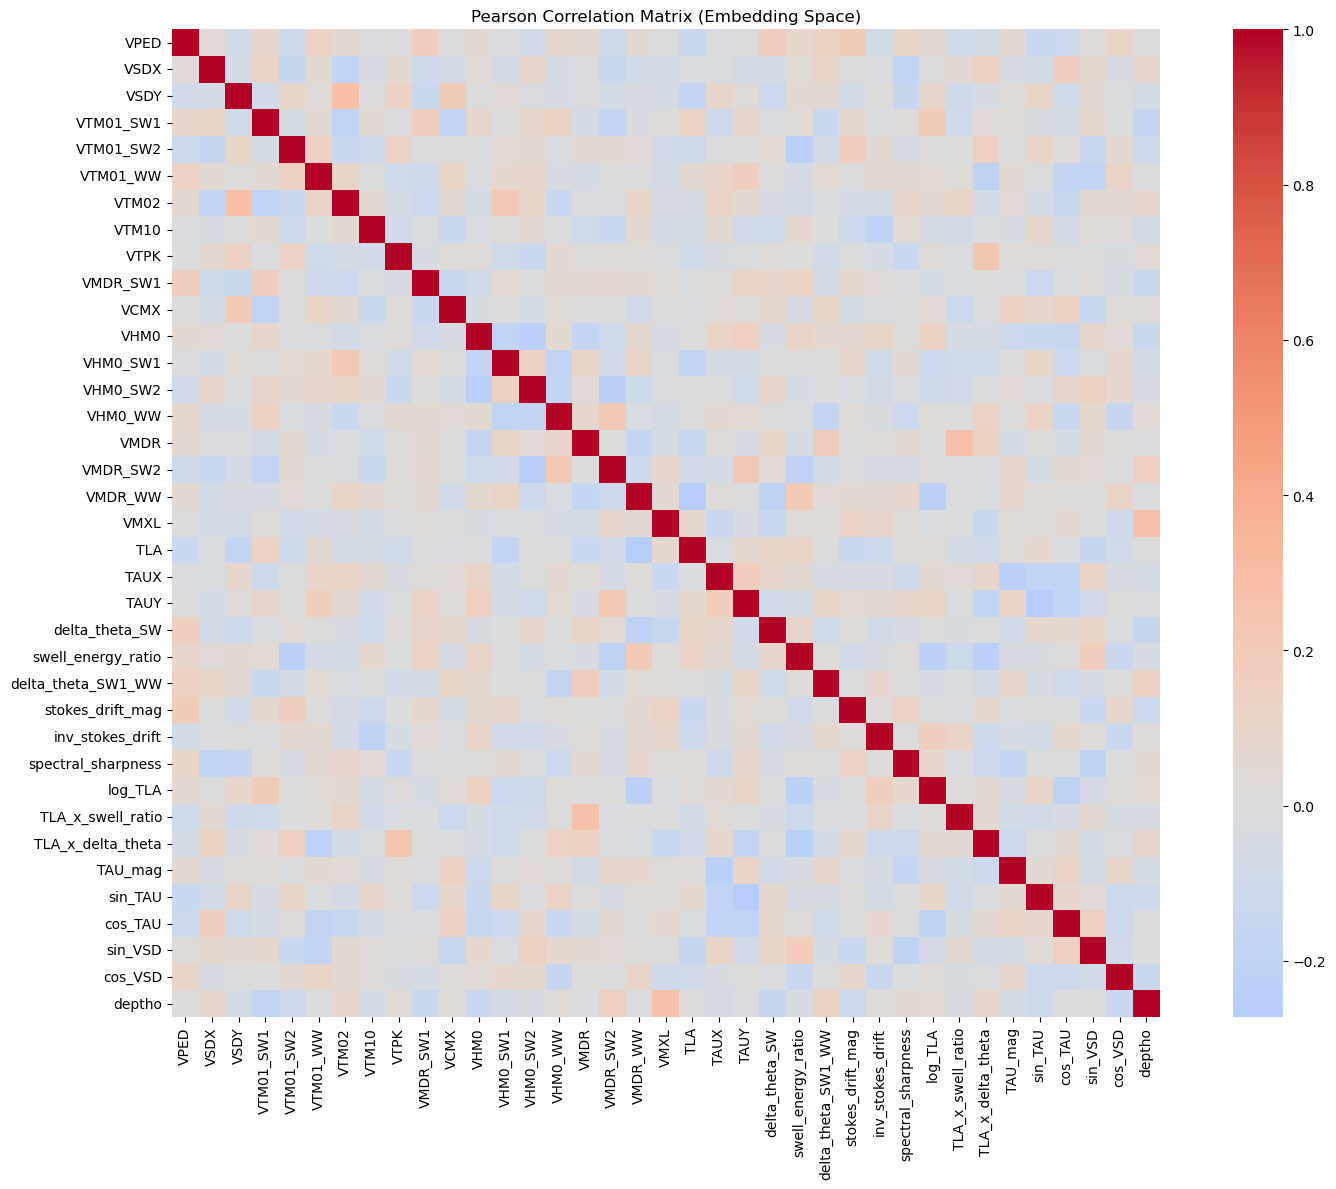

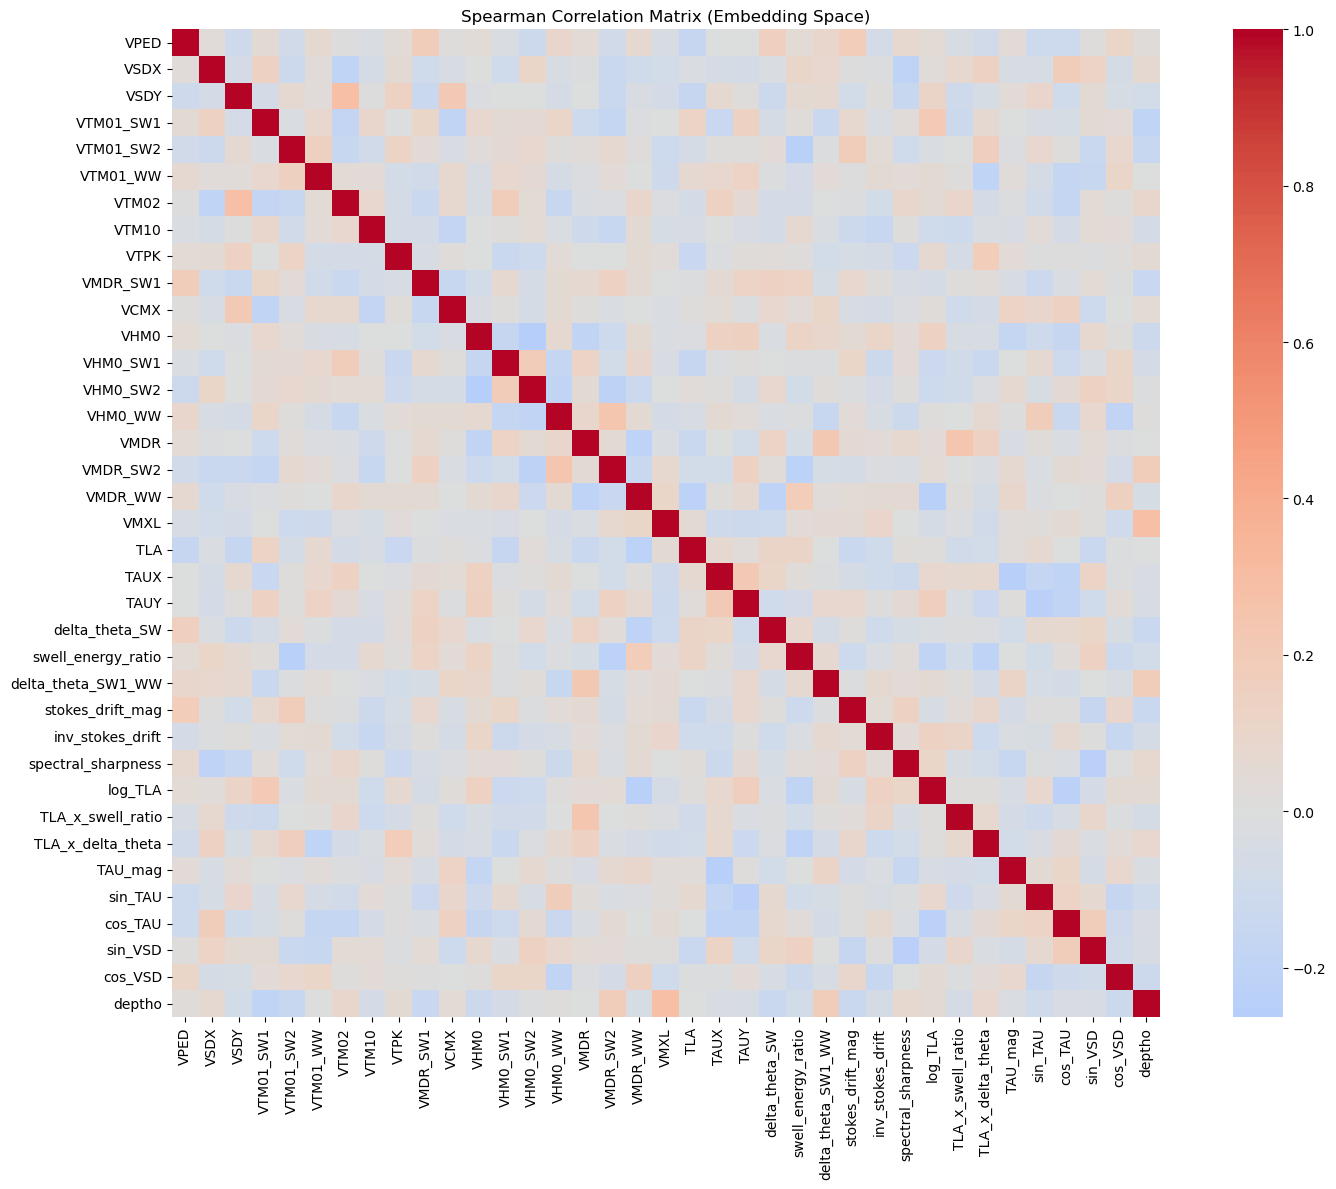

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. Load .npy file
# ==============================
# Data shape: (Time, 37, 128)
data = np.load("per_feature_embeddings.npy")
T, num_features, embed_dim = data.shape
print(f"Data shape: {data.shape}")

# ==============================
# 2. Map Actual Feature Names (Total 37)
# ==============================
# The order must match the concatenation in build_input_tensor()

feature_names = [
    # WAVE_VARS (9)
    'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK',
    # WAVE_VARS1 (10)
    'VMDR_SW1', 'VCMX', 'VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL',
    # EXTRA_VARS (3)
    'TLA', 'TAUX', 'TAUY',
    # Engineered Features (14)
    'delta_theta_SW', 'swell_energy_ratio', 'delta_theta_SW1_WW', 'stokes_drift_mag', 
    'inv_stokes_drift', 'spectral_sharpness', 'log_TLA', 'TLA_x_swell_ratio', 
    'TLA_x_delta_theta', 'TAU_mag', 'sin_TAU', 'cos_TAU', 'sin_VSD', 'cos_VSD',
    # Bathymetry (1)
    'deptho'
]

# ==============================
# 3. Reshape for Correlation
# ==============================
# We treat (Time * EmbeddingDim) as observations for each feature.
# Transpose (T, 37, 128) -> (T, 128, 37) then reshape to (-1, 37)
data_reshaped = data.transpose(0, 2, 1).reshape(-1, num_features)

df = pd.DataFrame(data_reshaped, columns=feature_names)

# ==============================
# 4. Remove constant / invalid columns
# ==============================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=1, how="any")

# Drop zero-variance features
df = df.loc[:, df.std() > 0]
print(f"Usable features: {df.shape[1]}")

# ==============================
# 5. Compute Correlations
# ==============================
pearson_corr = df.corr(method="pearson")
spearman_corr = df.corr(method="spearman")

# ==============================
# 6. Plot Pearson correlation
# ==============================
plt.figure(figsize=(16, 12))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=True, 
    yticklabels=True
)
plt.title("Pearson Correlation Matrix (Embedding Space)")
plt.tight_layout()
plt.savefig("pearson_correlation.png")
plt.show()

# ==============================
# 7. Plot Spearman correlation
# ==============================
plt.figure(figsize=(16, 12))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=True, 
    yticklabels=True
)
plt.title("Spearman Correlation Matrix (Embedding Space)")
plt.tight_layout()
plt.savefig("spearman_correlation.png")
plt.show()

# ==============================
# 8. Save correlation matrices
# ==============================
pearson_corr.to_csv("pearson_corr.csv")
spearman_corr.to_csv("spearman_corr.csv")